<div style="background:linear-gradient(135deg,#042f2e 0%,#0f766e 55%,#14b8a6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#99f6e4;font-weight:700;text-transform:uppercase">Chapter 38 · Probability Distributions</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Continuous Distributions 📈</div>
  <div style="font-size:15px;color:#d1fae5;max-width:740px;line-height:1.6">When a quantity can take any value on a scale, probability becomes area under a curve. This notebook builds the density function, the uniform and exponential, the normal, and the CDF, then fits a Gaussian by maximum likelihood, the assumption behind least squares.</div>
  <div style="margin-top:16px;font-size:13px;color:#a7f3d0">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
rng = np.random.default_rng(38)
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
TEAL="#0d9488"; PINK="#db2777"; AMBER="#d97706"
print("ready")

ready


<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 1 · MASS BECOMES DENSITY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Probability is area under the curve</div>
<div style="color:#4a5578;margin-top:6px">A continuous variable has a probability DENSITY function (PDF), not a mass function. The height is not a probability; the AREA between two points is. The probability of any exact value is zero.</div>
</div>

In [2]:
data = rng.normal(0, 1, size=100_000)
xs = np.linspace(-4, 4, 400)
pdf = stats.norm.pdf(xs)

# P(0.5 < X < 1.5) is the area under the PDF between 0.5 and 1.5
area = stats.norm.cdf(1.5) - stats.norm.cdf(0.5)
print(f"P(0.5 < X < 1.5) = {area:.4f}")
print(f"empirical fraction in (0.5,1.5) = {np.mean((data>0.5)&(data<1.5)):.4f}")

P(0.5 < X < 1.5) = 0.2417
empirical fraction in (0.5,1.5) = 0.2389


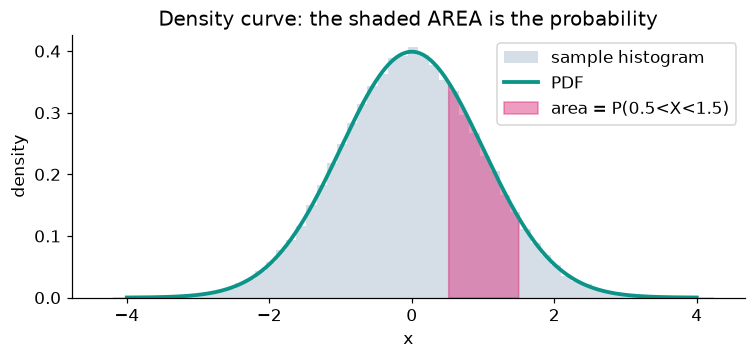

In [3]:
fig,ax=plt.subplots(figsize=(7,3.4))
ax.hist(data, bins=60, density=True, color="#cbd5e1", alpha=0.8, label="sample histogram")
ax.plot(xs, pdf, color=TEAL, lw=2.5, label="PDF")
mask=(xs>=0.5)&(xs<=1.5)
ax.fill_between(xs[mask], pdf[mask], color=PINK, alpha=0.45, label="area = P(0.5<X<1.5)")
ax.set_xlabel("x"); ax.set_ylabel("density"); ax.set_title("Density curve: the shaded AREA is the probability"); ax.legend()
plt.tight_layout(); plt.show()

The histogram of a large sample traces out the PDF. Probability is the shaded **area**, here P(0.5 < X < 1.5) = 0.2417, matched by the empirical fraction. Because a single point has zero width, P(X = exactly 1) = 0; only intervals carry probability.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 2 · UNIFORM &amp; EXPONENTIAL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Flat odds, and waiting times</div>
<div style="color:#4a5578;margin-top:6px">The uniform distribution spreads probability evenly over an interval. The exponential models the waiting time until a random event, with mean 1/lambda, and it is memoryless.</div>
</div>

In [4]:
lam = 0.5            # rate; mean waiting time = 1/lam = 2
wait = rng.exponential(1/lam, size=200_000)
print(f"exponential mean 1/lambda = {1/lam}, simulated mean = {wait.mean():.3f}")

# memoryless: P(X > 3 | X > 2) = P(X > 1)
p_cond = np.mean(wait[wait>2] > 3)
print(f"P(X>3 | X>2) = {p_cond:.3f}   vs   P(X>1) = {np.exp(-lam*1):.3f}")

exponential mean 1/lambda = 2.0, simulated mean = 1.995
P(X>3 | X>2) = 0.605   vs   P(X>1) = 0.607


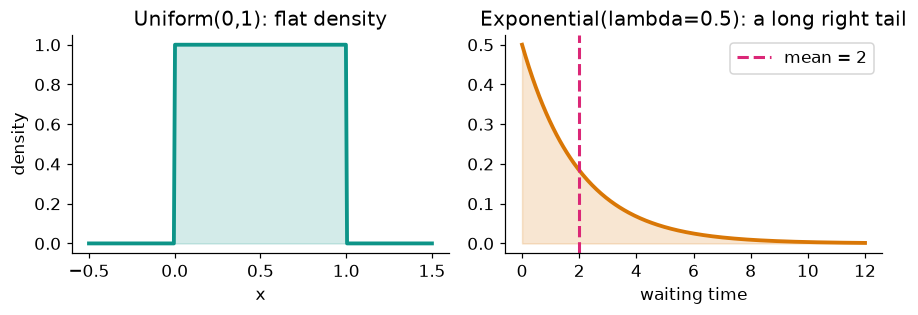

In [5]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(8.4,3))
xu=np.linspace(-0.5,1.5,300)
a1.plot(xu, stats.uniform.pdf(xu,0,1), color=TEAL, lw=2.5)
a1.fill_between(xu, stats.uniform.pdf(xu,0,1), color=TEAL, alpha=0.18)
a1.set_title("Uniform(0,1): flat density"); a1.set_xlabel("x"); a1.set_ylabel("density")
xe=np.linspace(0,12,300)
a2.plot(xe, stats.expon.pdf(xe,scale=1/lam), color=AMBER, lw=2.5)
a2.fill_between(xe, stats.expon.pdf(xe,scale=1/lam), color=AMBER, alpha=0.18)
a2.axvline(1/lam, color=PINK, ls="--", lw=2, label="mean = 2")
a2.set_title("Exponential(lambda=0.5): a long right tail"); a2.set_xlabel("waiting time"); a2.legend()
plt.tight_layout(); plt.show()

The exponential is the continuous cousin of the geometric: both model "how long until the first event", and both are **memoryless**, having already waited 2 units tells you nothing about the remaining wait. P(X>3 | X>2) equals P(X>1), about 0.607.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 3 · THE NORMAL DISTRIBUTION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The bell curve and its two knobs</div>
<div style="color:#4a5578;margin-top:6px">The normal (Gaussian) is the most important continuous distribution. Its mean mu sets the center; its standard deviation sigma sets the width. Chapter 39 explores it in depth.</div>
</div>

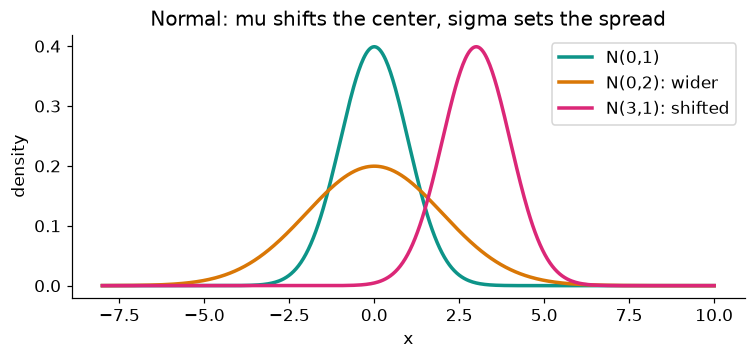

In [6]:
xs=np.linspace(-8,10,500)
fig,ax=plt.subplots(figsize=(7,3.4))
for mu,sd,c,lab in [(0,1,TEAL,"N(0,1)"),(0,2,AMBER,"N(0,2): wider"),(3,1,PINK,"N(3,1): shifted")]:
    ax.plot(xs, stats.norm.pdf(xs,mu,sd), color=c, lw=2.3, label=lab)
ax.set_xlabel("x"); ax.set_ylabel("density"); ax.set_title("Normal: mu shifts the center, sigma sets the spread"); ax.legend()
plt.tight_layout(); plt.show()

Every normal curve is the same bell, relocated by mu and stretched by sigma. A larger sigma spreads the same total area of 1 over a wider range, so the peak is lower. This single shape, justified by the Central Limit Theorem (Chapter 40), describes a startling amount of the natural world.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 4 · THE CDF, QUANTILES &amp; GAMMA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">From density to cumulative probability</div>
<div style="color:#4a5578;margin-top:6px">The cumulative distribution function (CDF) gives P(X <= x), the area to the left. Inverting it gives quantiles (percentiles). The gamma family adds flexible right-skewed shapes.</div>
</div>

In [7]:
print(f"P(X <= 1.5) for N(0,1)        = {stats.norm.cdf(1.5):.4f}")
print(f"95th percentile of N(0,1)     = {stats.norm.ppf(0.95):.4f}")
print(f"P(X <= 5) for Exponential(0.5) = {stats.expon.cdf(5, scale=2):.4f}")

P(X <= 1.5) for N(0,1)        = 0.9332
95th percentile of N(0,1)     = 1.6449
P(X <= 5) for Exponential(0.5) = 0.9179


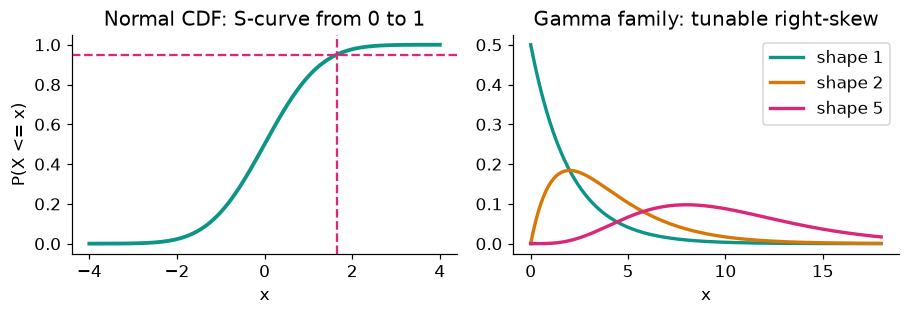

In [8]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(8.4,3))
xs=np.linspace(-4,4,400)
a1.plot(xs, stats.norm.cdf(xs), color=TEAL, lw=2.5)
a1.axhline(0.95, color=PINK, ls="--", lw=1.5); a1.axvline(stats.norm.ppf(0.95), color=PINK, ls="--", lw=1.5)
a1.set_title("Normal CDF: S-curve from 0 to 1"); a1.set_xlabel("x"); a1.set_ylabel("P(X <= x)")
xg=np.linspace(0,18,400)
for k,c,lab in [(1,TEAL,"shape 1"),(2,AMBER,"shape 2"),(5,PINK,"shape 5")]:
    a2.plot(xg, stats.gamma.pdf(xg,k,scale=2), color=c, lw=2.2, label=lab)
a2.set_title("Gamma family: tunable right-skew"); a2.set_xlabel("x"); a2.legend()
plt.tight_layout(); plt.show()

The CDF rises from 0 to 1; reading across at 0.95 and down gives the 95th percentile, 1.645 for the standard normal. The **gamma** distribution (a sum of exponentials) flexes from sharply skewed to nearly bell-shaped as its shape parameter grows, which is why it models waiting times, rainfall, and insurance claims.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 5 · FITTING A GAUSSIAN</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Maximum likelihood and least squares</div>
<div style="color:#4a5578;margin-top:6px">Fitting a normal to data by maximum likelihood gives mu_hat = the sample mean and sigma_hat = the sample standard deviation. Assuming Gaussian noise is exactly what makes least-squares regression optimal.</div>
</div>

In [9]:
sample = rng.normal(170, 8, size=500)        # e.g. heights in cm
mu_hat, sigma_hat = sample.mean(), sample.std()
print(f"MLE mu_hat    = {mu_hat:.2f}  (sample mean)")
print(f"MLE sigma_hat = {sigma_hat:.2f}  (sample std)")

MLE mu_hat    = 170.01  (sample mean)
MLE sigma_hat = 8.22  (sample std)


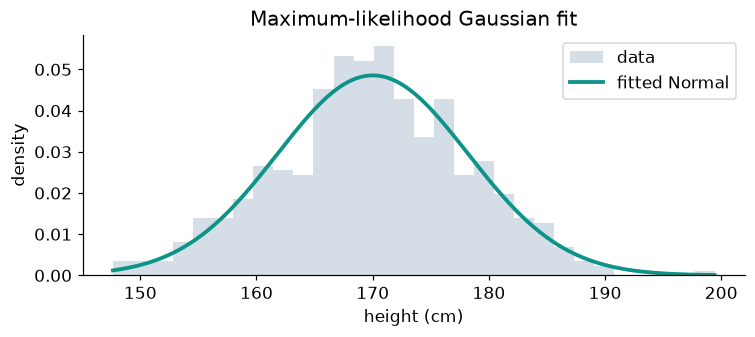

In [10]:
fig,ax=plt.subplots(figsize=(7,3.2))
ax.hist(sample, bins=30, density=True, color="#cbd5e1", alpha=0.8, label="data")
xs=np.linspace(sample.min(),sample.max(),300)
ax.plot(xs, stats.norm.pdf(xs,mu_hat,sigma_hat), color=TEAL, lw=2.5, label="fitted Normal")
ax.set_xlabel("height (cm)"); ax.set_ylabel("density"); ax.set_title("Maximum-likelihood Gaussian fit"); ax.legend()
plt.tight_layout(); plt.show()

The maximum-likelihood Gaussian recovers the data's mean and spread. This matters far beyond curve-fitting: if you assume the errors of a model are normally distributed, then **minimizing squared error is the same as maximizing the likelihood**. The Gaussian is why "least squares" is the default in regression and deep learning.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ What you built</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You saw probability become area under a density, met the uniform, exponential, normal, and gamma, used the CDF to get probabilities and quantiles, and fit a Gaussian by maximum likelihood. Continuous distributions are the language of measurement, and the normal, next chapter, is their crown jewel.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>